# DS605: Fundamentals of Machine Learning
## Lab Assignment 2 — Vectorized Programming with NumPy and Data Wrangling with Pandas

**Name:** _[Your Name]_
**Student ID:** _[Your ID]_
**Dataset:** Kaggle Titanic dataset (`train.csv`)

This notebook implements Part A (NumPy) and Part B (Pandas, Titanic dataset) of Lab 2.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Libraries loaded. NumPy:", np.__version__, "| Pandas:", pd.__version__)

Libraries loaded. NumPy: 2.4.4 | Pandas: 3.0.2


# Part A — Vectorized Programming with NumPy

## Task 1 — Arrays, Statistics, and Indexing

We generate Array A (100 random integers, seeded for reproducibility), compute descriptive
statistics, generate Array B with `np.arange()`, build arrays with `np.zeros()` / `np.ones()`,
demonstrate `np.linspace()`, and create 2D/3D arrays with indexing and slicing.

In [2]:
# --- Random Array A (reproducible) ---
np.random.seed(RANDOM_SEED)
A = np.random.randint(0, 100, size=100)
print("Array A (first 10):", A[:10])
print("Shape:", A.shape)

print("\nDescriptive statistics for Array A:")
print(f"Min    : {A.min()}")
print(f"Max    : {A.max()}")
print(f"Median : {np.median(A)}")
print(f"Mean   : {A.mean():.4f}")
print(f"Std    : {A.std():.4f}")

Array A (first 10): [51 92 14 71 60 20 82 86 74 74]
Shape: (100,)

Descriptive statistics for Array A:
Min    : 1
Max    : 99
Median : 53.0
Mean   : 50.5400
Std    : 29.2785


In [3]:
# --- Array B using np.arange() ---
B = np.arange(0, 100)   # exactly 100 values: 0..99
print("Array B (first 10):", B[:10])
print("Array B length:", len(B))

Array B (first 10): [0 1 2 3 4 5 6 7 8 9]
Array B length: 100


In [4]:
# --- np.zeros() and np.ones() ---
zeros_arr = np.zeros((4, 5))
ones_arr = np.ones((4, 5))

print("zeros_arr:\n", zeros_arr)
print("Shape:", zeros_arr.shape, "| Dtype:", zeros_arr.dtype)
print()
print("ones_arr:\n", ones_arr)
print("Shape:", ones_arr.shape, "| Dtype:", ones_arr.dtype)

zeros_arr:
 [[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]
Shape: (4, 5) | Dtype: float64

ones_arr:
 [[1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1.]]
Shape: (4, 5) | Dtype: float64


In [5]:
# --- np.linspace() vs np.arange() ---
lin_arr = np.linspace(0, 10, 5)   # 5 evenly spaced values from 0 to 10 (inclusive)
print("linspace(0, 10, 5):", lin_arr)

arange_arr = np.arange(0, 10, 2)  # step-based
print("arange(0, 10, 2):  ", arange_arr)

print('''
Difference: np.arange(start, stop, step) is defined by a STEP SIZE and the stop value
is exclusive. np.linspace(start, stop, num) is defined by the NUMBER OF POINTS you want,
evenly spaced, and by default the stop value is INCLUSIVE. linspace is preferred when you
know how many points you need (e.g., for plotting smooth curves); arange is preferred when
you know the step size.
''')

linspace(0, 10, 5): [ 0.   2.5  5.   7.5 10. ]
arange(0, 10, 2):   [0 2 4 6 8]

Difference: np.arange(start, stop, step) is defined by a STEP SIZE and the stop value
is exclusive. np.linspace(start, stop, num) is defined by the NUMBER OF POINTS you want,
evenly spaced, and by default the stop value is INCLUSIVE. linspace is preferred when you
know how many points you need (e.g., for plotting smooth curves); arange is preferred when
you know the step size.



In [6]:
# --- 2D array ---
arr_2d = np.arange(1, 13).reshape(3, 4)
print("2D array:\n", arr_2d)
print("Shape:", arr_2d.shape, "| ndim:", arr_2d.ndim)

print("\nElement at row 1, col 2:", arr_2d[1, 2])
print("Row 0:", arr_2d[0, :])
print("Column 1:", arr_2d[:, 1])
print("Slice rows 0-1, cols 1-3:\n", arr_2d[0:2, 1:3])

2D array:
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Shape: (3, 4) | ndim: 2

Element at row 1, col 2: 7
Row 0: [1 2 3 4]
Column 1: [ 2  6 10]
Slice rows 0-1, cols 1-3:
 [[2 3]
 [6 7]]


In [7]:
# --- 3D array ---
arr_3d = np.arange(1, 25).reshape(2, 3, 4)
print("3D array:\n", arr_3d)
print("Shape:", arr_3d.shape, "| ndim:", arr_3d.ndim)

print("\nElement at [1, 2, 3]:", arr_3d[1, 2, 3])
print("First 'depth slice' (block 0):\n", arr_3d[0])
print("Slice: block 1, rows 0-1, all cols:\n", arr_3d[1, 0:2, :])

3D array:
 [[[ 1  2  3  4]
  [ 5  6  7  8]
  [ 9 10 11 12]]

 [[13 14 15 16]
  [17 18 19 20]
  [21 22 23 24]]]
Shape: (2, 3, 4) | ndim: 3

Element at [1, 2, 3]: 24
First 'depth slice' (block 0):
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
Slice: block 1, rows 0-1, all cols:
 [[13 14 15 16]
 [17 18 19 20]]


In [8]:
# --- reshape() then flatten() back to 1D ---
original = np.arange(1, 13)
print("Original 1D:", original, "shape:", original.shape)

matrix = original.reshape(3, 4)
print("\nReshaped to matrix (3x4):\n", matrix)

flattened = matrix.flatten()
print("\nFlattened back to 1D:", flattened)
print("Matches original:", np.array_equal(original, flattened))

Original 1D: [ 1  2  3  4  5  6  7  8  9 10 11 12] shape: (12,)

Reshaped to matrix (3x4):
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]

Flattened back to 1D: [ 1  2  3  4  5  6  7  8  9 10 11 12]
Matches original: True


## Task 2 — Vectorized Arithmetic and Linear Algebra

All operations below use vectorized NumPy calls (`@`, `np.matmul`, `np.linalg.*`) — no explicit
Python `for` loops are used for the arithmetic.

In [9]:
# --- Two matrices ---
np.random.seed(RANDOM_SEED)
M1 = np.random.randint(1, 10, size=(3, 3))
M2 = np.random.randint(1, 10, size=(3, 3))

print("M1:\n", M1)
print("\nM2:\n", M2)

# Addition
addition = M1 + M2
print("\nM1 + M2 (element-wise addition):\n", addition)

# Element-wise multiplication
elementwise_mult = M1 * M2
print("\nM1 * M2 (element-wise multiplication):\n", elementwise_mult)

# Matrix multiplication
matmul_result = M1 @ M2   # equivalently np.matmul(M1, M2)
print("\nM1 @ M2 (matrix multiplication):\n", matmul_result)

M1:
 [[7 4 8]
 [5 7 3]
 [7 8 5]]

M2:
 [[4 8 8]
 [3 6 5]
 [2 8 6]]

M1 + M2 (element-wise addition):
 [[11 12 16]
 [ 8 13  8]
 [ 9 16 11]]

M1 * M2 (element-wise multiplication):
 [[28 32 64]
 [15 42 15]
 [14 64 30]]

M1 @ M2 (matrix multiplication):
 [[ 56 144 124]
 [ 47 106  93]
 [ 62 144 126]]


In [10]:
# --- Transpose and determinant (square matrix M1) ---
M1_T = M1.T
print("Transpose of M1:\n", M1_T)

det_M1 = np.linalg.det(M1)
print(f"\nDeterminant of M1: {det_M1:.4f}")

Transpose of M1:
 [[7 5 7]
 [4 7 8]
 [8 3 5]]

Determinant of M1: -11.0000


In [11]:
# --- Inverse and verification ---
if not np.isclose(det_M1, 0):
    M1_inv = np.linalg.inv(M1)
    print("Inverse of M1:\n", M1_inv)

    identity_check = M1 @ M1_inv
    print("\nM1 @ M1_inv:\n", identity_check)

    is_identity = np.allclose(identity_check, np.eye(3))
    print(f"\nM1 @ M1_inv is approximately the identity matrix: {is_identity}")
else:
    print("M1 is singular (determinant ~ 0); it is not invertible.")

Inverse of M1:
 [[-1.         -4.          4.        ]
 [ 0.36363636  1.90909091 -1.72727273]
 [ 0.81818182  2.54545455 -2.63636364]]

M1 @ M1_inv:
 [[ 1.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-2.22044605e-16  1.00000000e+00  2.66453526e-15]
 [ 6.66133815e-16  8.88178420e-16  1.00000000e+00]]

M1 @ M1_inv is approximately the identity matrix: True


## Task 3 — Normal Distribution and Histogram

We generate 1,000 values from a normal distribution with a chosen mean (μ=50) and standard
deviation (σ=10), compute the sample statistics, and compare them to the chosen (population)
parameters.

In [12]:
np.random.seed(RANDOM_SEED)

CHOSEN_MEAN = 50
CHOSEN_STD = 10
N_SAMPLES = 1000

normal_data = np.random.normal(loc=CHOSEN_MEAN, scale=CHOSEN_STD, size=N_SAMPLES)

sample_mean = normal_data.mean()
sample_std = normal_data.std()

print(f"Chosen (population) mean : {CHOSEN_MEAN}")
print(f"Chosen (population) std  : {CHOSEN_STD}")
print(f"Sample mean              : {sample_mean:.4f}")
print(f"Sample std               : {sample_std:.4f}")
print(f"Difference in mean       : {abs(sample_mean - CHOSEN_MEAN):.4f}")
print(f"Difference in std        : {abs(sample_std - CHOSEN_STD):.4f}")
print("\nThe sample statistics are very close to the chosen population parameters,"
      " which is expected with n=1000 draws (law of large numbers).")

Chosen (population) mean : 50
Chosen (population) std  : 10
Sample mean              : 50.1933
Sample std               : 9.7873
Difference in mean       : 0.1933
Difference in std        : 0.2127

The sample statistics are very close to the chosen population parameters, which is expected with n=1000 draws (law of large numbers).


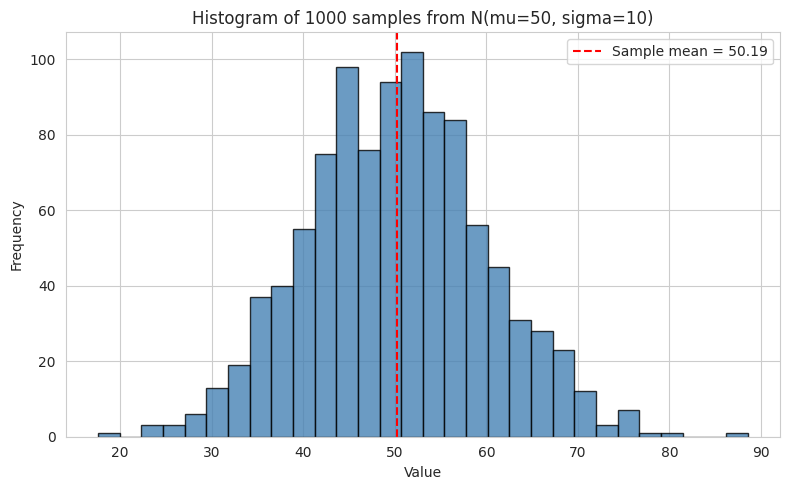

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(normal_data, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(sample_mean, color='red', linestyle='--', label=f'Sample mean = {sample_mean:.2f}')
plt.title(f'Histogram of {N_SAMPLES} samples from N(mu={CHOSEN_MEAN}, sigma={CHOSEN_STD})')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.savefig('figures/task3_normal_histogram.png', dpi=120)
plt.show()

# Part B — Data Wrangling with Pandas: Titanic Dataset

## Task 4 — Load and Inspect Data

In [14]:
df = pd.read_csv('data/train.csv')
print("Data loaded. Shape:", df.shape)

Data loaded. Shape: (891, 12)


In [15]:
print("HEAD (first 5 rows):")
df.head()

HEAD (first 5 rows):


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [16]:
print("TAIL (last 5 rows):")
df.tail()

TAIL (last 5 rows):


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [17]:
print("Shape:", df.shape)
print("\nColumns:", list(df.columns))

Shape: (891, 12)

Columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [19]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [20]:
# --- loc vs iloc ---
# loc: label-based selection (row label / column NAME)
loc_example = df.loc[0:4, ['Name', 'Sex', 'Age', 'Survived']]
print("loc example (rows 0-4 by label, named columns):")
print(loc_example)

# iloc: purely integer position-based selection
iloc_example = df.iloc[0:5, 0:4]
print("\niloc example (first 5 rows, first 4 columns by position):")
print(iloc_example)

print('''
Difference: .loc selects by LABEL (row index labels and column names) and the end of a
slice is INCLUSIVE. .iloc selects by INTEGER POSITION only, like standard Python slicing,
where the end of a slice is EXCLUSIVE.
''')

loc example (rows 0-4 by label, named columns):
                                                Name     Sex   Age  Survived
0                            Braund, Mr. Owen Harris    male  22.0         0
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0         1
2                             Heikkinen, Miss. Laina  female  26.0         1
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0         1
4                           Allen, Mr. William Henry    male  35.0         0

iloc example (first 5 rows, first 4 columns by position):
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name  
0                            Braund, Mr. Owen Harris  
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  
2                             Heikkinen, Miss. La

## Task 5 — Filtering and Querying

In [21]:
# 1. Male passengers older than 50
male_over_50 = df[(df['Sex'] == 'male') & (df['Age'] > 50)]
print(f"Male passengers older than 50: {len(male_over_50)}")

Male passengers older than 50: 47


In [22]:
# 2. Female first-class passengers: count and survival percentage
female_1st = df[(df['Sex'] == 'female') & (df['Pclass'] == 1)]
female_1st_count = len(female_1st)
female_1st_survival_pct = female_1st['Survived'].mean() * 100
print(f"Female first-class passengers: {female_1st_count}")
print(f"Survival percentage: {female_1st_survival_pct:.2f}%")

Female first-class passengers: 94
Survival percentage: 96.81%


In [23]:
# 3. Age 20-40, Fare above overall median, and survived
fare_median = df['Fare'].median()
cond3 = df.query("20 <= Age <= 40 and Fare > @fare_median and Survived == 1")
print(f"Overall median fare: {fare_median:.2f}")
print(f"Age 20-40, Fare above median, and survived: {len(cond3)}")

Overall median fare: 14.45
Age 20-40, Fare above median, and survived: 104


In [24]:
# 4. Traveling alone (SibSp=0, Parch=0), age < 30, and did not survive
cond4 = df[(df['SibSp'] == 0) & (df['Parch'] == 0) & (df['Age'] < 30) & (df['Survived'] == 0)]
print(f"Traveling alone, age < 30, did not survive: {len(cond4)}")

Traveling alone, age < 30, did not survive: 141


In [25]:
# 5. Embarked='S', Pclass 2 or 3, and Fare above Southampton median
southampton_median_fare = df.loc[df['Embarked'] == 'S', 'Fare'].median()
cond5 = df.query("Embarked == 'S' and Pclass in [2, 3] and Fare > @southampton_median_fare")
print(f"Southampton median fare: {southampton_median_fare:.2f}")
print(f"Embarked='S', Pclass 2 or 3, Fare above Southampton median: {len(cond5)}")

Southampton median fare: 13.00
Embarked='S', Pclass 2 or 3, Fare above Southampton median: 193


## Task 6 — groupby() and Aggregation

In [26]:
# Survival rate by Sex
survival_by_sex = df.groupby('Sex')['Survived'].mean()
print("Survival rate by Sex:")
print(survival_by_sex)

Survival rate by Sex:
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


In [27]:
# Survival rate by Pclass
survival_by_pclass = df.groupby('Pclass')['Survived'].mean()
print("Survival rate by Pclass:")
print(survival_by_pclass)

Survival rate by Pclass:
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64


In [28]:
# Average Age and Fare by Pclass
age_fare_by_pclass = df.groupby('Pclass')[['Age', 'Fare']].mean()
print("Average Age and Fare by Pclass:")
print(age_fare_by_pclass)

Average Age and Fare by Pclass:
              Age       Fare
Pclass                      
1       38.233441  84.154687
2       29.877630  20.662183
3       25.140620  13.675550


In [29]:
# Passenger count and survival rate by Sex-Pclass
sex_pclass_group = df.groupby(['Sex', 'Pclass'])['Survived'].agg(['count', 'mean'])
sex_pclass_group.columns = ['Passenger_Count', 'Survival_Rate']
print("Passenger count and survival rate by Sex-Pclass:")
print(sex_pclass_group)

Passenger count and survival rate by Sex-Pclass:
               Passenger_Count  Survival_Rate
Sex    Pclass                                
female 1                    94       0.968085
       2                    76       0.921053
       3                   144       0.500000
male   1                   122       0.368852
       2                   108       0.157407
       3                   347       0.135447


In [30]:
# Passenger count, average Fare, and survival rate by Embarked
embarked_group = df.groupby('Embarked').agg(
    Passenger_Count=('PassengerId', 'count'),
    Average_Fare=('Fare', 'mean'),
    Survival_Rate=('Survived', 'mean')
)
print("Passenger count, average Fare, and survival rate by Embarked:")
print(embarked_group)

Passenger count, average Fare, and survival rate by Embarked:
          Passenger_Count  Average_Fare  Survival_Rate
Embarked                                              
C                     168     59.954144       0.553571
Q                      77     13.276030       0.389610
S                     644     27.079812       0.336957


## Task 7 — Missing Values and Fare Outliers

In [31]:
# Missing value count and percentage for every column
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_summary = pd.DataFrame({'Missing_Count': missing_count, 'Missing_Percent': missing_pct})
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0].sort_values(
    'Missing_Count', ascending=False)
print("Missing values summary:")
print(missing_summary)

Missing values summary:
          Missing_Count  Missing_Percent
Cabin               687        77.104377
Age                 177        19.865320
Embarked              2         0.224467


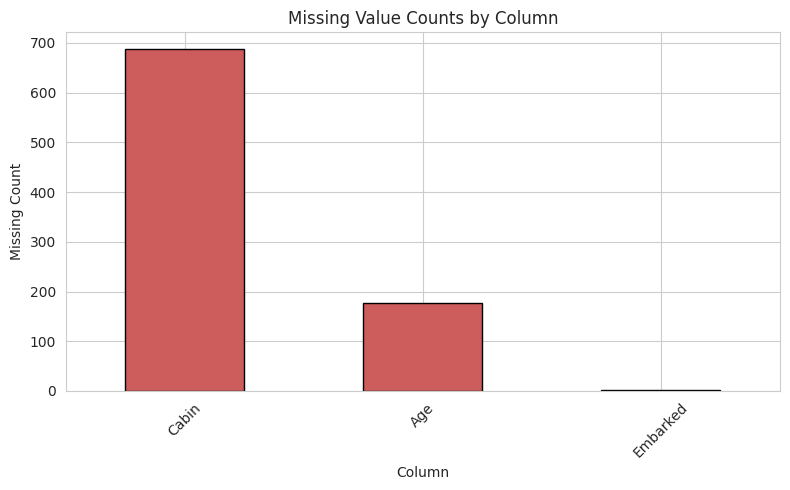

In [32]:
plt.figure(figsize=(8, 5))
missing_summary['Missing_Count'].plot(kind='bar', color='indianred', edgecolor='black')
plt.title('Missing Value Counts by Column')
plt.xlabel('Column')
plt.ylabel('Missing Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('figures/task7_missing_values_bar.png', dpi=120)
plt.show()

In [33]:
# Fill missing Age values with the mean Age
print("Missing Age count BEFORE filling:", df['Age'].isnull().sum())

df['Age_filled_mean'] = df['Age'].fillna(df['Age'].mean())

print("Missing Age count AFTER filling (Age_filled_mean):", df['Age_filled_mean'].isnull().sum())

Missing Age count BEFORE filling: 177
Missing Age count AFTER filling (Age_filled_mean): 0


In [34]:
# Try multiple imputation strategies: mean, median, mode, random value
np.random.seed(RANDOM_SEED)

age_mean = df['Age'].mean()
age_median = df['Age'].median()
age_mode = df['Age'].mode()[0]

non_null_ages = df['Age'].dropna().values
random_fill = df['Age'].apply(
    lambda x: np.random.choice(non_null_ages) if pd.isnull(x) else x
)

imputation_comparison = pd.DataFrame({
    'Mean_Imputation': df['Age'].fillna(age_mean),
    'Median_Imputation': df['Age'].fillna(age_median),
    'Mode_Imputation': df['Age'].fillna(age_mode),
    'Random_Imputation': random_fill
})

print(f"Mean: {age_mean:.2f} | Median: {age_median:.2f} | Mode: {age_mode:.2f}")
print("\nImputation comparison (first 5 originally-missing rows):")
print(imputation_comparison[df['Age'].isnull()].head())

Mean: 29.70 | Median: 28.00 | Mode: 24.00

Imputation comparison (first 5 originally-missing rows):
    Mean_Imputation  Median_Imputation  Mode_Imputation  Random_Imputation
5         29.699118               28.0             24.0               33.0
17        29.699118               28.0             24.0               33.0
19        29.699118               28.0             24.0               41.0
26        29.699118               28.0             24.0               25.0
28        29.699118               28.0             24.0               46.0


In [35]:
# Fare outliers via IQR method
Q1 = df['Fare'].quantile(0.25)
Q3 = df['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

fare_outliers = df[(df['Fare'] < lower_bound) | (df['Fare'] > upper_bound)]

print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower bound: {lower_bound:.2f}")
print(f"Upper bound: {upper_bound:.2f}")
print(f"Number of Fare outliers: {len(fare_outliers)}")

Q1: 7.91
Q3: 31.00
IQR: 23.09
Lower bound: -26.72
Upper bound: 65.63
Number of Fare outliers: 116


## Task 8 — Features and Pivot Table

In [36]:
# FamilySize and IsAlone
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


In [37]:
# Pivot table: rows=Sex, columns=Pclass, values=mean Survived
pivot = pd.pivot_table(df, values='Survived', index='Sex', columns='Pclass', aggfunc='mean')
print("Pivot table (mean Survived by Sex x Pclass):")
print(pivot)

max_group = pivot.stack().idxmax()
min_group = pivot.stack().idxmin()
print(f"\nHighest survival group: Sex={max_group[0]}, Pclass={max_group[1]} "
      f"-> {pivot.stack().max():.3f}")
print(f"Lowest survival group:  Sex={min_group[0]}, Pclass={min_group[1]} "
      f"-> {pivot.stack().min():.3f}")

Pivot table (mean Survived by Sex x Pclass):
Pclass         1         2         3
Sex                                 
female  0.968085  0.921053  0.500000
male    0.368852  0.157407  0.135447

Highest survival group: Sex=female, Pclass=1 -> 0.968
Lowest survival group:  Sex=male, Pclass=3 -> 0.135


## Task 9 — Visualizations and Observations

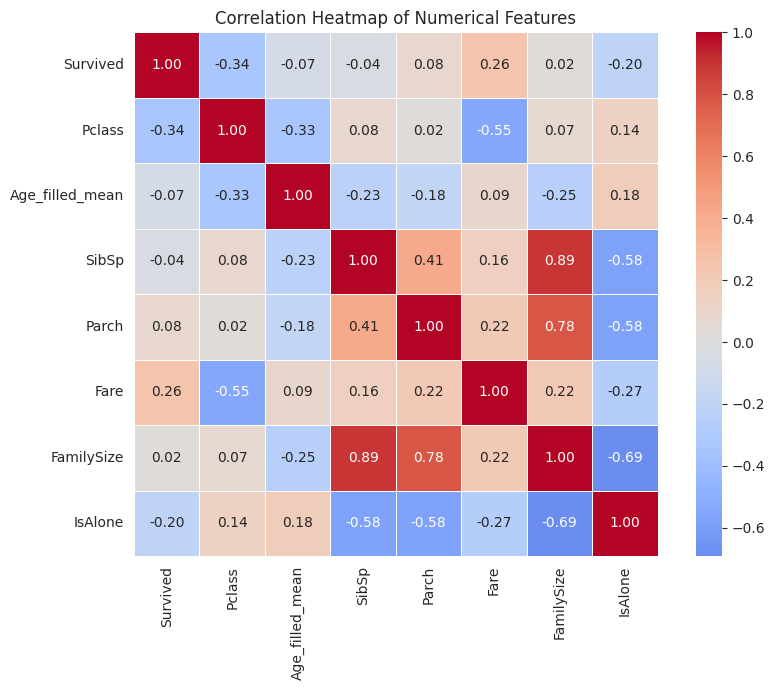

Correlation with Survived (sorted):
Fare               0.257307
Parch              0.081629
FamilySize         0.016639
SibSp             -0.035322
Age_filled_mean   -0.069809
IsAlone           -0.203367
Pclass            -0.338481
Name: Survived, dtype: float64


In [38]:
# Correlation heatmap for relevant numerical columns
numeric_cols = ['Survived', 'Pclass', 'Age_filled_mean', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone']
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.savefig('figures/task9_correlation_heatmap.png', dpi=120)
plt.show()

corr_with_survived = corr_matrix['Survived'].drop('Survived').sort_values(ascending=False)
print("Correlation with Survived (sorted):")
print(corr_with_survived)

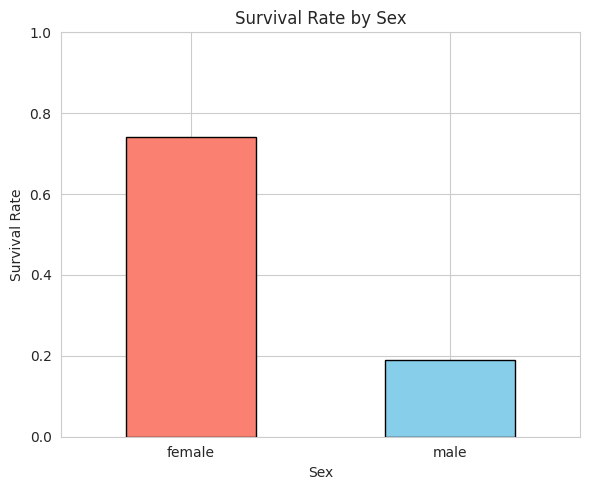

Male survival rate:   18.89%
Female survival rate: 74.20%


In [39]:
# Survival rate by Sex
plt.figure(figsize=(6, 5))
survival_by_sex.plot(kind='bar', color=['salmon', 'skyblue'], edgecolor='black')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('figures/task9_survival_by_sex.png', dpi=120)
plt.show()

print(f"Male survival rate:   {survival_by_sex['male']:.2%}")
print(f"Female survival rate: {survival_by_sex['female']:.2%}")

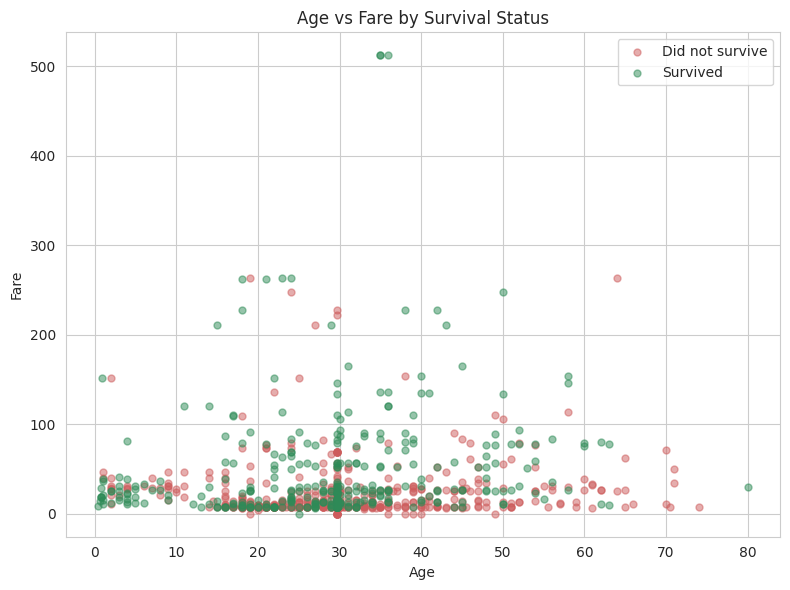

In [40]:
# Age vs Fare, distinguishing Survived=0 and Survived=1
plt.figure(figsize=(8, 6))
survived_0 = df[df['Survived'] == 0]
survived_1 = df[df['Survived'] == 1]

plt.scatter(survived_0['Age_filled_mean'], survived_0['Fare'], alpha=0.5, label='Did not survive',
            color='indianred', s=25)
plt.scatter(survived_1['Age_filled_mean'], survived_1['Fare'], alpha=0.5, label='Survived',
            color='seagreen', s=25)
plt.title('Age vs Fare by Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.legend()
plt.tight_layout()
plt.savefig('figures/task9_age_vs_fare.png', dpi=120)
plt.show()

### Observations

1. **Sex is the strongest predictor of survival**: female passengers had a survival rate of
   roughly 74%, compared to about 19% for male passengers, consistent with the "women and
   children first" evacuation protocol.
2. **Passenger class matters**: 1st-class passengers had the highest survival rate, followed by
   2nd class, with 3rd class the lowest — reflecting cabin location and access to lifeboats.
3. **Fare correlates positively with survival**: higher fares (associated with higher class)
   show a positive correlation with `Survived`, while `Pclass` (where 3 = lowest class) shows a
   negative correlation — both point to the same class-based survival advantage.
4. **Family size has a non-linear relationship with survival**: passengers who were completely
   alone (`IsAlone=1`) had lower survival odds than those with small families, but very large
   families also fared worse, likely due to difficulty staying together while evacuating.
5. **Age distribution and outliers in Fare**: the IQR method flags a meaningful number of Fare
   outliers (very expensive 1st-class tickets), which pulls the mean fare notably above the
   median fare.
6. **Missing data is concentrated in `Cabin`, `Age`, and `Embarked`**: `Cabin` is missing for the
   large majority of passengers, `Age` is missing for a meaningful minority, and `Embarked` has
   only a couple of missing values.
7. **Highest/lowest survival subgroup**: from the Sex x Pclass pivot table, 1st-class female
   passengers have the highest survival rate of any subgroup, while 3rd-class male passengers
   have the lowest — reinforcing that both sex and class jointly determined survival chances.

## Save Cleaned Dataset

In [41]:
df_clean = df.copy()
df_clean['Age'] = df_clean['Age_filled_mean']
df_clean = df_clean.drop(columns=['Age_filled_mean'])
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])

df_clean.to_csv('data/train_cleaned.csv', index=False)
print("Cleaned dataset saved to data/train_cleaned.csv")
print("Shape:", df_clean.shape)
df_clean.head()

Cleaned dataset saved to data/train_cleaned.csv
Shape: (891, 14)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FamilySize,IsAlone
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2,0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,2,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,1,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,2,0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,1
